# 🧠 Data Exploration Notebook

This notebook serves as the **first step** in the end-to-end machine learning workflow. Its purpose is to **understand and explore the structure and quality of the dataset**, setting the stage for effective preprocessing and modeling later on.

---

### 📌 Notebook Objective

In this notebook, we aim to:
- Load and inspect the dataset
- Understand feature types (categorical vs. numerical)
- Explore the target variable (`readmitted`) and clarify the classification setup
- Identify and address potential data quality issues (e.g., missing values, imbalance, redundancy)
- Partition the data for structured exploration of categorical features

---

### 🔍 Why This Matters

A solid understanding of the dataset at this stage:
- Helps avoid downstream issues during modeling
- Reveals patterns that may influence preprocessing choices
- Surfaces early indicators of informative or problematic features

---

### 🧭 Next Steps in the Workflow

The insights gathered here will directly inform the steps in the following notebooks:
- `02_preprocessing_and_feature_engineering.ipynb`
- `03_model_training_and_evaluation.ipynb`
- `04_model_explainability.ipynb`
---
---

## 📊 Exploring the Fundamentals of the Data

In this section, we begin by importing the dataset and performing an initial review to understand its structure and contents.

The goal here is to:
- Get a sense of the dataset's **size and shape**
- Examine **column types** and identify **feature categories** (numerical, categorical, identifiers, etc.)
- Review the **target variable** and how we will frame the prediction task

This exploration lays the groundwork for more detailed analysis and data preparation in the next stages.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant



# Setting the plot style
sns.set(style='whitegrid')


In [5]:
df = pd.read_csv('../data/diabetes.csv')
df.head(10)


,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,6,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,7,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,8,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,>30
8,9,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,10,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Observations of the data
The main goal of this project is to predict whether a diabetic patient will be readmitted to the hospital within 30 days of discharge. With this objective in mind, we begin by examining and understanding the structure of the dataset to identify patterns and potential predictors of readmission.

The dataset contains both numerical (e.g., number of medications, time in hospital) and categorical (e.g., race, gender, diagnosis codes) features. In total, there are 50 columns (features) and 101,766 rows, where each row represents a single hospital visit by a patient. It’s important to note that the same patient may appear multiple times, as the dataset logs individual encounters rather than unique individuals.

Furthermore, which will be important in the second part, we have a lot of values in the data that are marked as '?', which is probably a string value. These are in addition to NaN values, concidered missing values and needs to be taken into account. 


C:\Users\Elias\AppData\Local\Temp\ipykernel_12732\33173601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='readmitted', data=df, palette='pastel', order=['<30', '>30', 'NO'])


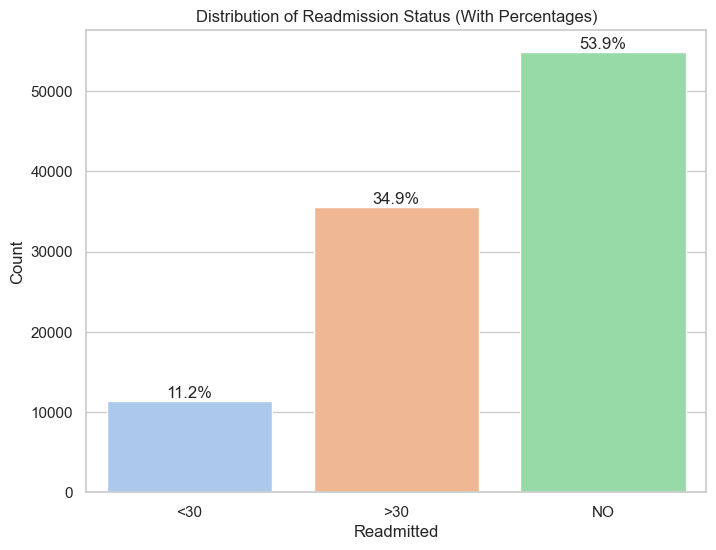

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [6]:
# Visualizing the distribution of the 'readmitted' column (target variable)
plt.figure(figsize=(8,6))
ax = sns.countplot(x='readmitted', data=df, palette='pastel', order=['<30', '>30', 'NO'])

# Add percentage labels on top of bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('Distribution of Readmission Status (With Percentages)')
plt.xlabel('Readmitted')
plt.ylabel('Count')
plt.show()


df['readmitted'].value_counts()

### Observations on Target Variable (`readmitted`)

The target variable contains three classes:

- `<30`: Readmitted within 30 days (11.2%)
- `>30`: Readmitted after 30 days (34.9%)
- `NO`: Not readmitted (53.9%)

However, since we are only interested in wheter the patient was re-admittes within 30 days or not we can remake this into a binary classification, where we simply merge those who have not been re-admitted at all with those who were re-admitted after 30 days. This results in the following binary class. 

- `<30`: Readmitted within 30 days (11.2%)
- `>30 || NO`: Readmitted after 30 days (88.8%)

Thus it is evident that the data is very **imbalanced**. This is important to acknowledge early because it can lead to very biased models, that is a model that achieves high accuracy of predicition without actually learning anything useful. In order to prevent this we will need to: 

- Use evaluation metrics that are better suited for imbalanced data such as **F1-score**, **precision/recall**, and **ROC-AUC** instead of just accuracy (even though accuracy is rarley a good metric).
- Concider different techniques during model training such as **Class weighting**, **Oversampling** or **Undersampling**, depending on the model.
- Be careful durin **train-test splitting** to avoid an unbalanced class distribution.

So in summary, we will treat this as a binary classification problem and only focus on predicitng wheter the patient will be re-admitted within 30 days **or not**. Since the positive class is underrepresented, strategies to combat this will need to be concidered.


C:\Users\Elias\AppData\Local\Temp\ipykernel_12732\427610618.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=binary_target, palette='pastel')


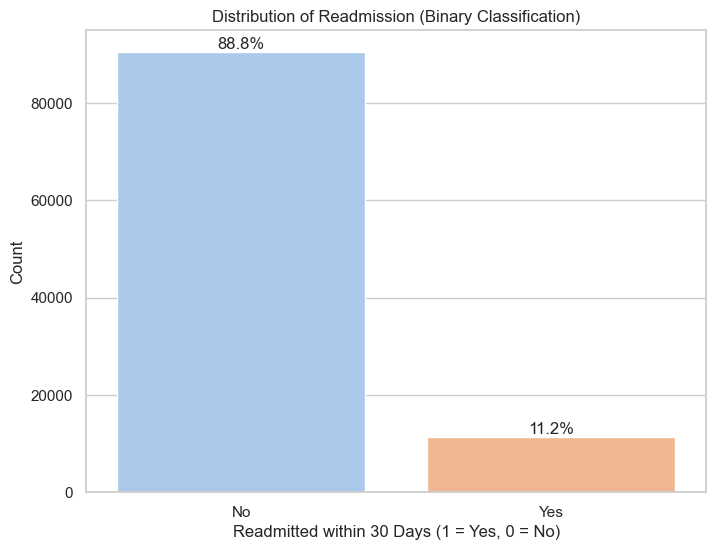

In [7]:
# Visualizing the binary distribution of the 'readmitted' column, after mergin.
# Create a temporary Series to represent the binary version of 'readmitted'
binary_target = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Plot the distribution
plt.figure(figsize=(8,6))
ax = sns.countplot(x=binary_target, palette='pastel')

# Add percentage labels
total = len(binary_target)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.title('Distribution of Readmission (Binary Classification)')
plt.xlabel('Readmitted within 30 Days (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No', 'Yes'])  # Optional: label the x-axis
plt.show()


## 🧼 Exploring Missing Values, Distributions, and Correlations

In this section, we take a deeper look at data quality and variable behavior, with a focus on identifying challenges and opportunities for modeling.

Specifically, we will:
- Detect and quantify **missing or placeholder values** (e.g., `'?'`,`'NaN'`, etc  )
- Examine **categorical feature distributions** to spot class imbalance or inconsistent values
- Analyze **numerical feature distributions** for skewness, outliers, or sparsity
- Explore basic **correlations** between numeric variables to identify redundancy or relationships

These insights will inform our decisions in the preprocessing and feature engineering steps that follow.


#### Checking for NaN and missing values ('?')

In [8]:
# Check for NaN values
NaN_counts = df.isnull().sum().sort_values(ascending=False)
print("🔍 Missing (NaN) Values:")
display(NaN_counts[NaN_counts > 0])

# Check for '?' values
question_mark_counts = (df == '?').sum().sort_values(ascending=False)
print("\n🔍 Placeholder '?' Values:")
display(question_mark_counts[question_mark_counts > 0])


🔍 Missing (NaN) Values:


max_glu_serum    96420
A1Cresult        84748
dtype: int64


🔍 Placeholder '?' Values:


weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

### Cleaning Up the Data Enough to Explore it - Dividing into Cathegorical and Numerical data 


In [9]:
# Creating a copy of the DataFrame to avoid modifying the original
df_copy = df.copy()

# Values that are typically concidered placerholder values
placeholder_values = [
    'na', 'Na', 'NA',
    'NaN', 'nan', 'NAN',
    'n/a', 'N/A', 'N\A',
    'n.a.', 'N.A.', 'n.a', 'N.A',
    '?', '-', '--', '.', '*'
]

# Converting placeholder values to NaN
df_copy = df_copy.replace(placeholder_values, pd.NA)

# Dividingng the columns into categorical and numerical features 
categorical_features = df_copy.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
numerical_features = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Catching missplaced columns across the two lists

# Features that have codes (categorical feature) but could be numerical in the data. from IDS_mapping.csv and 
# https://datasets.aim-ahead.net/dataset/p/UCI_DS_296

hidden_cateogircal_features = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

for feature in hidden_cateogircal_features:
    if feature in numerical_features:
        numerical_features.remove(feature)
    if feature not in categorical_features:
        categorical_features.append(feature)


# Removing the target variable from the list of features
target = 'readmitted'

if target in categorical_features: 
    categorical_features.remove(target)
elif target in numerical_features:
    numerical_features.remove(target)


# Generating the categorical and numerical DatFrames
df_categorical = df_copy[categorical_features].copy()
df_numerical = df_copy[numerical_features].copy()

# Test to see if all the columns have been subsetted from the original DataFrame, expect the target variable
if len(categorical_features) + len(numerical_features) != len(df.columns) - 1:
    print('There is a problem with unaccounted columns. Please check the data and code')
else:
    print('No unaccounted columns found')


<>:8: SyntaxWarning: invalid escape sequence '\A'
<>:8: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Elias\AppData\Local\Temp\ipykernel_12732\2403404256.py:8: SyntaxWarning: invalid escape sequence '\A'
  'n/a', 'N/A', 'N\A',


No unaccounted columns found


#### Summary
Up until this point the data has been checked for NaN values, placeholder values and then divided into numerical and categorical data. This is done on order to better explore the two parts of this data which will give us better knowledge of both parts. From data knowledge we could also adjust the categorical data disguised as numerical data to be where it fits, and lastly a check in order to see that we have not used any feature twice.

### Cathegorical Data

#### Displaying the categoircal data 

In [10]:
df_categorical.head(10)

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,admission_type_id,discharge_disposition_id,admission_source_id
0,Caucasian,Female,[0-10),<NA>,<NA>,Pediatrics-Endocrinology,250.83,<NA>,<NA>,NaN,...,No,No,No,No,No,No,No,6,25,1
1,Caucasian,Female,[10-20),<NA>,<NA>,<NA>,276,250.01,255,NaN,...,No,No,No,No,No,Ch,Yes,1,1,7
2,AfricanAmerican,Female,[20-30),<NA>,<NA>,<NA>,648,250,V27,NaN,...,No,No,No,No,No,No,Yes,1,1,7
3,Caucasian,Male,[30-40),<NA>,<NA>,<NA>,8,250.43,403,NaN,...,No,No,No,No,No,Ch,Yes,1,1,7
4,Caucasian,Male,[40-50),<NA>,<NA>,<NA>,197,157,250,NaN,...,No,No,No,No,No,Ch,Yes,1,1,7
5,Caucasian,Male,[50-60),<NA>,<NA>,<NA>,414,411,250,NaN,...,No,No,No,No,No,No,Yes,2,1,2
6,Caucasian,Male,[60-70),<NA>,<NA>,<NA>,414,411,V45,NaN,...,No,No,No,No,No,Ch,Yes,3,1,2
7,Caucasian,Male,[70-80),<NA>,<NA>,<NA>,428,492,250,NaN,...,No,No,No,No,No,No,Yes,1,1,7
8,Caucasian,Female,[80-90),<NA>,<NA>,<NA>,398,427,38,NaN,...,No,No,No,No,No,Ch,Yes,2,1,4
9,Caucasian,Female,[90-100),<NA>,<NA>,InternalMedicine,434,198,486,NaN,...,No,No,No,No,No,Ch,Yes,3,3,4


#### Observations of the Categorical Data  
Here, we can see that there are some binary categorical features, some with a large number of distinct values, and others that contain a significant amount of missing data. To make exploration more efficient and structured, we will partition the categorical features into four subsets:

1. Features with a high number of missing values. These will be grouped separately, as they are unlikely to provide much insight during exploration.
2. Features that are purely **binary** (i.e., exactly two unique values, NaN does not count for this).
3. Features with a few distinct values — specifically, between 3 and 10.
4. Features with **high cardinality**, meaning more than 10 unique values, but without a high proportion of missing data.

In the next section, this partitioning will be carried out explicitly.


### Partitioning the Cathegorical Data into Subsets Based on the Observations

#### Partitioning the Missing Values into its own subset and removing it from the cathegoical dataset

In [11]:
# Threshold for partitoning set at 35% of total numbers in a column missing.
threshold = 0.35 * len(df_categorical)

# Creating a subset with features that have a greater NaN value than the threshold
df_missing_values = df_categorical.loc[:, df_categorical.isnull().sum() > threshold]

# Displaying the features with high NaN values
print("Number of features with NaN values greater than the threshold: ", len(df_missing_values.columns))

# Dropping the features with high NaN values in the categorical DataFrame
for col in df_missing_values.columns:
    if col in df_categorical.columns:
        df_categorical.drop(col, axis =1 , inplace=True)

# Displaying the remaining categorical features
print("Remaining categorical features after dropping high NaN values:", len(df_categorical.columns))
df_categorical.head(10)


Number of features with NaN values greater than the threshold:  5
Remaining categorical features after dropping high NaN values: 34


,race,gender,age,diag_1,diag_2,diag_3,metformin,repaglinide,nateglinide,chlorpropamide,...,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,admission_type_id,discharge_disposition_id,admission_source_id
0,Caucasian,Female,[0-10),250.83,<NA>,<NA>,No,No,No,No,...,No,No,No,No,No,No,No,6,25,1
1,Caucasian,Female,[10-20),276,250.01,255,No,No,No,No,...,No,No,No,No,No,Ch,Yes,1,1,7
2,AfricanAmerican,Female,[20-30),648,250,V27,No,No,No,No,...,No,No,No,No,No,No,Yes,1,1,7
3,Caucasian,Male,[30-40),8,250.43,403,No,No,No,No,...,No,No,No,No,No,Ch,Yes,1,1,7
4,Caucasian,Male,[40-50),197,157,250,No,No,No,No,...,No,No,No,No,No,Ch,Yes,1,1,7
5,Caucasian,Male,[50-60),414,411,250,No,No,No,No,...,No,No,No,No,No,No,Yes,2,1,2
6,Caucasian,Male,[60-70),414,411,V45,Steady,No,No,No,...,No,No,No,No,No,Ch,Yes,3,1,2
7,Caucasian,Male,[70-80),428,492,250,No,No,No,No,...,No,No,No,No,No,No,Yes,1,1,7
8,Caucasian,Female,[80-90),398,427,38,No,No,No,No,...,No,No,No,No,No,Ch,Yes,2,1,4
9,Caucasian,Female,[90-100),434,198,486,No,No,No,No,...,No,No,No,No,No,Ch,Yes,3,3,4


#### Partitioning Binary Data

In [12]:
# Getting the column names where we exactly 2 unique values (i.e. its binary)
binary_cols = df_categorical.nunique()[df_categorical.nunique() == 2].index # note that NaN values are not counted

# Displaying the binary columns
print("Binary columns extraced from the categorical DataFrame:", binary_cols)
print("Number of binary columns:", len(binary_cols))

# Creating a new DataFrame consisting only of binary features
df_binary = df_categorical[binary_cols].copy()

# Displaying the binary DataFrame
df_binary.nunique()

Binary columns extraced from the categorical DataFrame: Index(['acetohexamide', 'tolbutamide', 'troglitazone', 'glipizide.metformin',
       'glimepiride.pioglitazone', 'metformin.rosiglitazone',
       'metformin.pioglitazone', 'change', 'diabetesMed'],
      dtype='object')
Number of binary columns: 9


acetohexamide               2
tolbutamide                 2
troglitazone                2
glipizide.metformin         2
glimepiride.pioglitazone    2
metformin.rosiglitazone     2
metformin.pioglitazone      2
change                      2
diabetesMed                 2
dtype: int64

#### Partitioning Categoriacal Data with classes in the range [3, 10]

In [13]:
# Creating a new DataFrame consisting only of non-binary categorical features
df_low_cardinality = df_categorical.loc[:, df_categorical.nunique().between(3, 10)].copy()

# Displaying found values 
print('Number of found features:', len(df_low_cardinality.columns))
df_low_cardinality.nunique()

Number of found features: 18


race                    5
gender                  3
age                    10
metformin               4
repaglinide             4
nateglinide             4
chlorpropamide          4
glimepiride             4
glipizide               4
glyburide               4
pioglitazone            4
rosiglitazone           4
acarbose                4
miglitol                4
tolazamide              3
insulin                 4
glyburide.metformin     4
admission_type_id       8
dtype: int64

#### Partitioning Categoriacal Data with feature that has more than 10 classes.

In [14]:
# Selecting categorical features with more than 10 unique classes (i.e., high cardinality)
df_high_cardinality = df_categorical.loc[:, df_categorical.nunique() > 10].copy()

# Displaying values found
print('Number of found features:', len(df_high_cardinality.columns))
df_high_cardinality.nunique()

Number of found features: 5


diag_1                      716
diag_2                      748
diag_3                      789
discharge_disposition_id     26
admission_source_id          17
dtype: int64

#### Quick Check that all values are accounted for

In [15]:
# Short function that checks if the features have less than 2 unique values
def check_missing_values(df):
    count = 0
    for col in df.columns:
        if df[col].nunique() < 2:
            print(col, 'has less than two unique values')
            count += 1
    return count


# Checking the number total number of partitoned features
num_of_partitioned_features = len(df_high_cardinality.columns) + len(df_low_cardinality.columns) + len(df_binary.columns)

# Comparing if all features have been accounted for
if num_of_partitioned_features != len(df_categorical.columns):
    print('There are unaccounted columns. Checking for potential reason...')
    
    print('\n...')
    # Checking if all unaccounted columns have less than 2 unique values
    count = check_missing_values(df_categorical)
    print('...\n')

    # Checking if all the unaccounted columns have less than 2 unique values
    delta_missing = len(df_categorical.columns) - num_of_partitioned_features

    if delta_missing != count:
        print('WARNING!! There are unaccounted columns with more than 2 unique values. Please check the data and code !!')
    else:
        print('All unaccounted columns have less than 2 unique values. There are no problems here.')
        df_unaccounted = df_categorical.loc[:, df_categorical.nunique() < 2].copy()

else:
    print('No unaccounted columns found')


There are unaccounted columns. Checking for potential reason...

...
examide has less than two unique values
citoglipton has less than two unique values
...

All unaccounted columns have less than 2 unique values. There are no problems here.


#### Displaying the remaining two cateogires that has only 1 class

In [16]:
df_unaccounted.head(10)

,examide,citoglipton
0,No,No
1,No,No
2,No,No
3,No,No
4,No,No
5,No,No
6,No,No
7,No,No
8,No,No
9,No,No


#### ✅ Partitioning Results

The partitioning process resulted in the following:

- `X` binary features (2 unique values)
- `Y` low-cardinality features (3–10 unique values)
- `Z` high-cardinality features (>10 unique values)
- `2` features removed for having fewer than 2 unique values

This structure allows us to more efficiently assess quality, imbalance, and encoding strategies tailored to each group in the next steps.


---
### Exploring the Categorical Data

Now that the categorical features have been cleaned and partitioned into three subsets — binary, low-cardinality, and high-cardinality — we can systematically explore their structure. The aim is to assess which features are informative and which may require transformation or removal prior to modeling.

For each subset, we will analyze the following:

1. **Class imbalance** — Features where one class dominates may not provide useful signal.
2. **Constant or low variance** — Features with little to no variation across samples are unlikely to be predictive.
3. **Missing values (`NaN`)** — Placeholder values such as `'unknown'`, `'N/A'`, `'other'`, etc. have already been replaced. We now evaluate actual missingness per feature.
4. **Redundancy & Outliers** — Some features may contain overlapping or duplicate information and may be redudant. Moreover, some classes may be unique in their respective feature - Not nececarily bad, but it is important to note. 




#### Exploring the Partitioned Binary Data

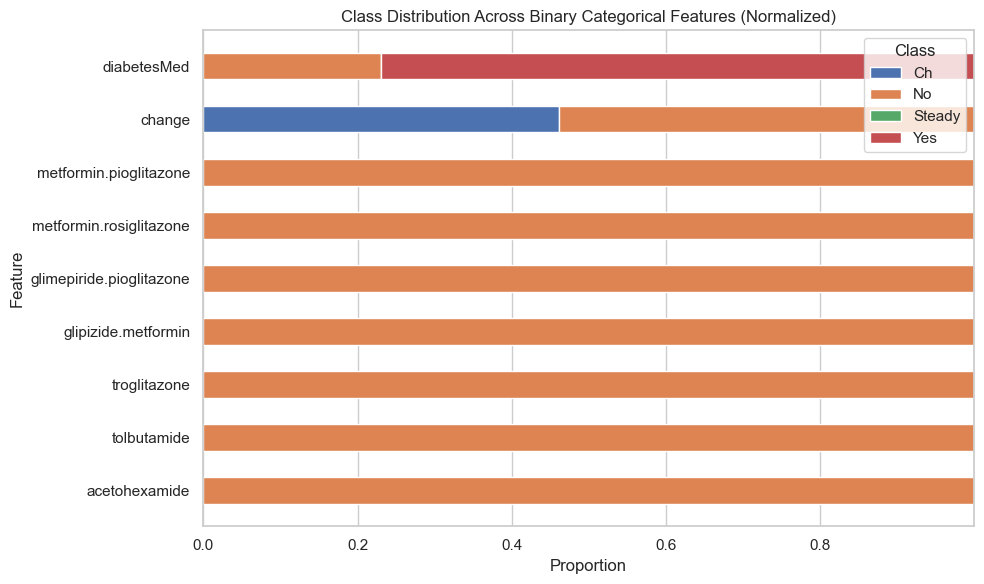

Features with a variance greater than 0.90
 acetohexamide                True
tolbutamide                  True
troglitazone                 True
glipizide.metformin          True
glimepiride.pioglitazone     True
metformin.rosiglitazone      True
metformin.pioglitazone       True
change                      False
diabetesMed                 False
dtype: bool

No NaN values found

No duplicate columns found.

Checking for high overlap between the binary features:

High overlap (1.00) between acetohexamide and tolbutamide
High overlap (1.00) between acetohexamide and troglitazone
High overlap (1.00) between acetohexamide and glipizide.metformin
High overlap (1.00) between acetohexamide and glimepiride.pioglitazone
High overlap (1.00) between acetohexamide and metformin.rosiglitazone
High overlap (1.00) between acetohexamide and metformin.pioglitazone
High overlap (1.00) between tolbutamide and troglitazone
High overlap (1.00) between tolbutamide and glipizide.metformin
High overlap (1.0

In [17]:
# 1.    Checking the class imbalance of the binary subset

# Get normalized value counts (percentage) for each binary feature
binary_dist = df_binary[binary_cols].apply(lambda x: x.value_counts(normalize=True)).T.fillna(0)

# Rename columns so they're consistent (e.g., Yes/No instead of actual values)
# Optional: reorder if needed
binary_dist = binary_dist[[col for col in binary_dist.columns]]  # Keeps existing order

# Plot
plt.figure(figsize=(10, 6))
bottom = None

# Plot each class (e.g., 'No', 'Yes') as a layer of the bar
for class_value in binary_dist.columns:
    plt.barh(
        binary_dist.index,
        binary_dist[class_value],
        label=str(class_value),
        left=bottom,
        height=0.5
    )
    if bottom is None:
        bottom = binary_dist[class_value].copy()
    else:
        bottom += binary_dist[class_value]

# Formatting
plt.title('Class Distribution Across Binary Categorical Features (Normalized)')
plt.xlabel('Proportion')
plt.ylabel('Feature')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

# 2.    Checking the variance of the binary subset 
print('Features with a variance greater than 0.90\n', binary_dist.max(axis=1) > 0.90)

# 3.    Evaluating i) If there exists missing values and ii) the missingnes of the binary subset 
print("\nNo NaN values found" if df_binary.isna().sum().sum() == 0 else f"NaN values found:\n{df_binary.isna().sum()}")

# 4.    Checking for Redundancy across Features

# i) Identifying duplicate columns — features that have exactly the same values across all rows.
duplicates = df_binary.T.duplicated(keep=False)
print("\nNo duplicate columns found." if not duplicates.any() else f"\nDuplicate columns found:\n{duplicates[duplicates]}")

# ii) Check features that have high similarity ≥ 95% overlap in values.
print('\nChecking for high overlap between the binary features:\n')
for i, col1 in enumerate(binary_cols):
    for j in range(i + 1, len(binary_cols)):
        col2 = binary_cols[j]
        # Calculating the overlap
        overlap = df_binary[col1].eq(df_binary[col2]).mean()
        
        if overlap >= 0.95:
            print(f"High overlap ({overlap:.2f}) between {col1} and {col2}")



#### ✅ Summary of Binary Categorical Feature Exploration

The exploration of binary categorical features reveals several key insights:

- **Severe Class Imbalance:**  
  Most features are heavily skewed toward a single class, with over 90% of observations falling into one category. This imbalance may reduce predictive power and can contribute to model bias if not handled during preprocessing.

- **Low Variance And Redundancy:**  
  7 of the 9 binary features exhibit extremely low variance and additionally, many of these features are **perfectly correlated** with each other (100% overlap), indicating **redundant information**. These features will likely be dropped or consolidated during preprocessing to reduce dimensionality.

- **Retained Informative Features:**  
  Only `change` and `diabetesMed` show meaningful variation and no redundancy. These features are very likely to retain some kind of value in the modeling pipeline process.

- **Data Quality:**  
  No missing values (`NaN`) were found, and no exact duplicate columns were detected.


#### Exploring the Partitioned Low-Cardinality Data

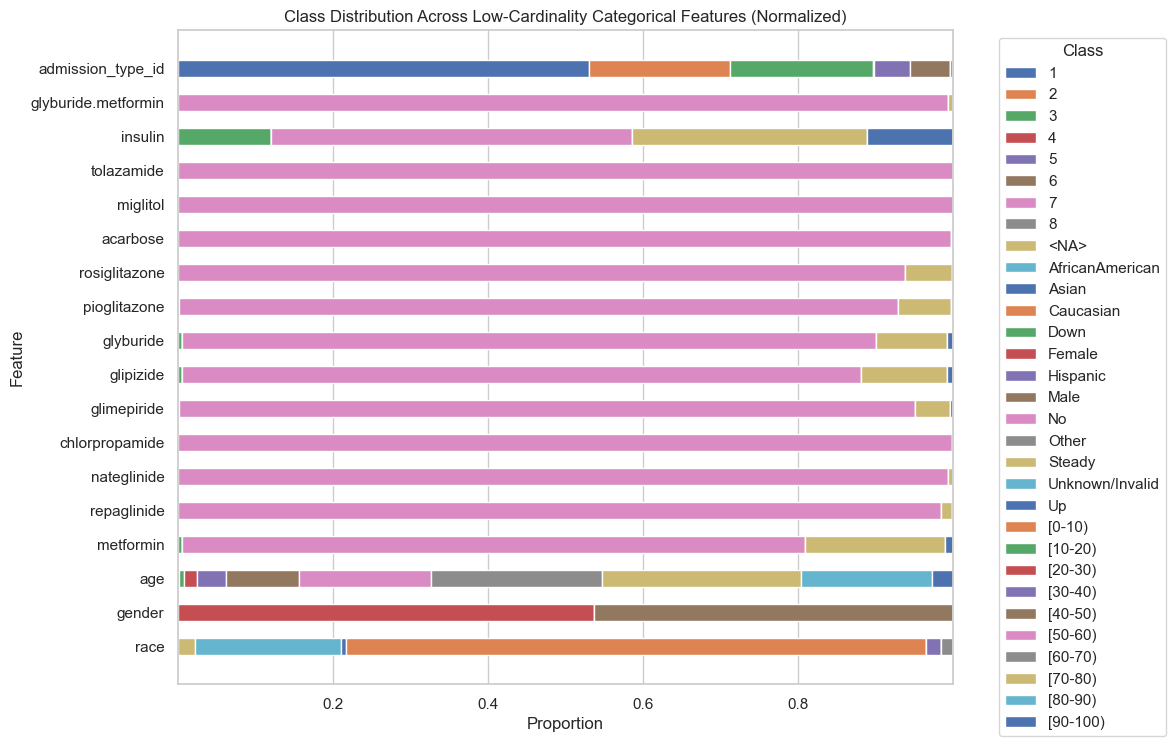

Features with a variance greater than 0.90
 race                   False
gender                 False
age                    False
metformin              False
repaglinide             True
nateglinide             True
chlorpropamide          True
glimepiride             True
glipizide              False
glyburide              False
pioglitazone            True
rosiglitazone           True
acarbose                True
miglitol                True
tolazamide              True
insulin                False
glyburide.metformin     True
admission_type_id      False
dtype: bool

NaN values found:
race                   2273
gender                    0
age                       0
metformin                 0
repaglinide               0
nateglinide               0
chlorpropamide            0
glimepiride               0
glipizide                 0
glyburide                 0
pioglitazone              0
rosiglitazone             0
acarbose                  0
miglitol                  0
tolazamide 

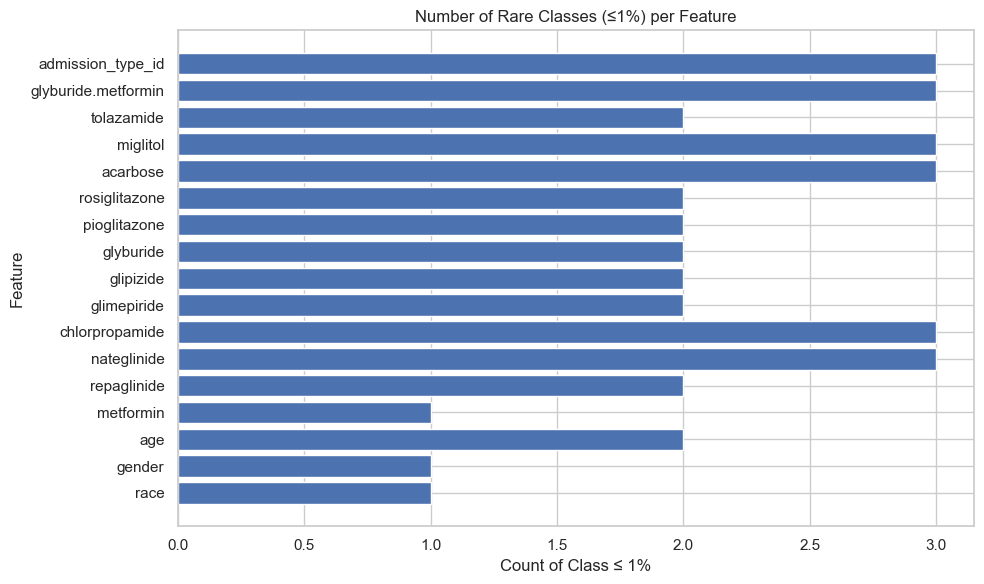

In [18]:
# 1.    Checking the class imbalance of the low-cardinality subset

# Creating a copy with purley strings (i.e., no mixed data types) used for plotting
df_low_cardinality_clean = df_low_cardinality.astype(str).copy()

# Get normalized value counts for each feature (transpose for plotting)
low_card_dist = df_low_cardinality_clean.apply(lambda x: x.value_counts(normalize=True)).T.fillna(0)

# Plotting class distributions
plt.figure(figsize=(12, 8))
bottom = None

for class_value in low_card_dist.columns:
    plt.barh(
        low_card_dist.index,
        low_card_dist[class_value],
        label=str(class_value),
        left=bottom,
        height=0.5
    )
    if bottom is None:
        bottom = low_card_dist[class_value].copy()
    else:
        bottom += low_card_dist[class_value]

plt.title('Class Distribution Across Low-Cardinality Categorical Features (Normalized)')
plt.xlabel('Proportion')
plt.ylabel('Feature')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2.    Checking the variance of the low-cardinality subset 
print('Features with a variance greater than 0.90\n', low_card_dist.max(axis=1) > 0.90)

# 3.    Evaluating i) If there exists missing values and ii) the missingnes of the low-cardinality subset 
print("\nNo NaN values found" if df_low_cardinality.isna().sum().sum() == 0 else f"\nNaN values found:\n{df_low_cardinality.isna().sum()}")


# 4.    Checking for Redundancy across Features

# i) Identifying duplicate columns — features that have exactly the same values across all rows.
duplicates_lc = df_low_cardinality.T.duplicated(keep=False)
print("\nNo duplicate columns found." if not duplicates_lc.any() else f"\nDuplicate columns found:\n{duplicates_lc[duplicates_lc]}")

# ii) Check features that have high similarity ≥ 95% overlap in values.
print('\nChecking for high overlap between the low-cardinality features (handling NaNs):\n')

lo_cols = df_low_cardinality.columns

for i, col1 in enumerate(lo_cols):
    for j in range(i + 1, len(lo_cols)):
        col2 = lo_cols[j]

        # Fill NaNs with a placeholder value before comparison
        s1 = df_low_cardinality[col1].fillna('___missing___')
        s2 = df_low_cardinality[col2].fillna('___missing___')

        overlap = (s1 == s2).mean()

        if overlap >= 0.95:
            print(f"High overlap ({overlap:.2f}) between {col1} and {col2}")


# iii) Check for "outliers" - I.e., classes that are very rare (< 1% of the total count)
rare_classes = []

for col in df_low_cardinality.columns:
    value_ratios = df_low_cardinality[col].value_counts(normalize=True)
    for category, ratio in value_ratios.items():
        if ratio <= 0.01:
            rare_classes.append((category, col))

# Visualizing rare classes found per feature
feature_counts = Counter([col for _, col in rare_classes])
plt.figure(figsize=(10, 6))
plt.barh(list(feature_counts.keys()), list(feature_counts.values()))
plt.title("Number of Rare Classes (≤1%) per Feature")
plt.xlabel("Count of Class ≤ 1%")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



#### Summary

The low-cardinality subset (features with 3–10 unique values) consists of 18 categorical variables. These were explored to understand their distribution, potential redundancy, and informativeness. The following insights were observed:

- **Class Imbalance:**  
  Most features exhibit **class imbalances**, where one category dominates the distribution which could reduce predictive power and may require resampling or grouping rare categories later.

- **Low Variance Features:**  
  Over half of the features have **very low variance**, with more than 90% of observations falling into a single class. These features may provide limited value for modeling and are potential candidates for removal or transformation.

- **Missing Values:**  
  Only one feature (`race`) contains missing data (~2.2%), which is manageable and can either be imputed or handled separately during preprocessing.

- **Redundancy (Feature Overlap ≥ 95%):**  
  Several features were found to be **highly overlapping or even fully redundant**. However, These features likely represent flags for rarely used medications and will probably be merged or dropped during preprocessing to reduce dimensionality.

- **Rare Class Detection (≤1% of Total):**  
  Several features contain categories that appear in fewer than 1% of samples. These outliers were identified and visualized. Features with multiple rare classes may require encoding strategies or grouping to ensure generalizability and minimize noise.



#### Exploring the Partitioned High-Cardinality Data

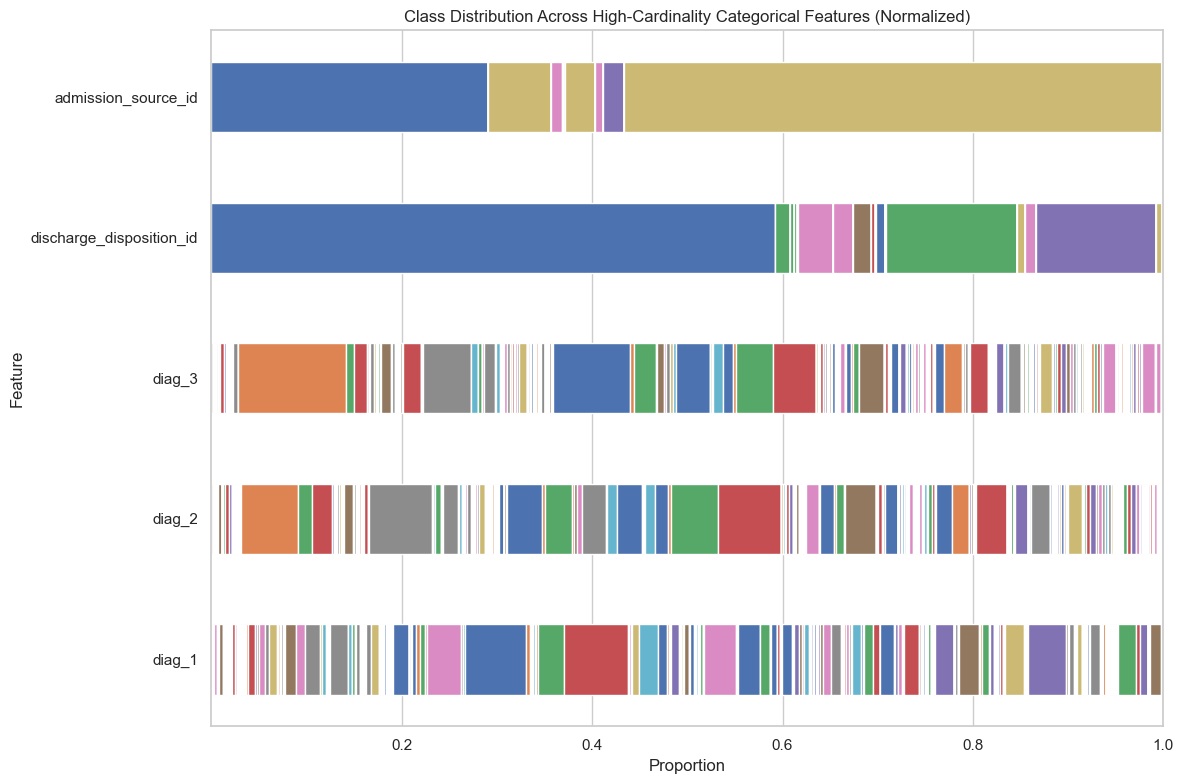

Features with a variance greater than 0.90
 diag_1                      False
diag_2                      False
diag_3                      False
discharge_disposition_id    False
admission_source_id         False
dtype: bool

NaN values found:
diag_1                        21
diag_2                       358
diag_3                      1423
discharge_disposition_id       0
admission_source_id            0
dtype: int64

No duplicate columns found.

Checking for high overlap between the low-cardinality features (handling NaNs):



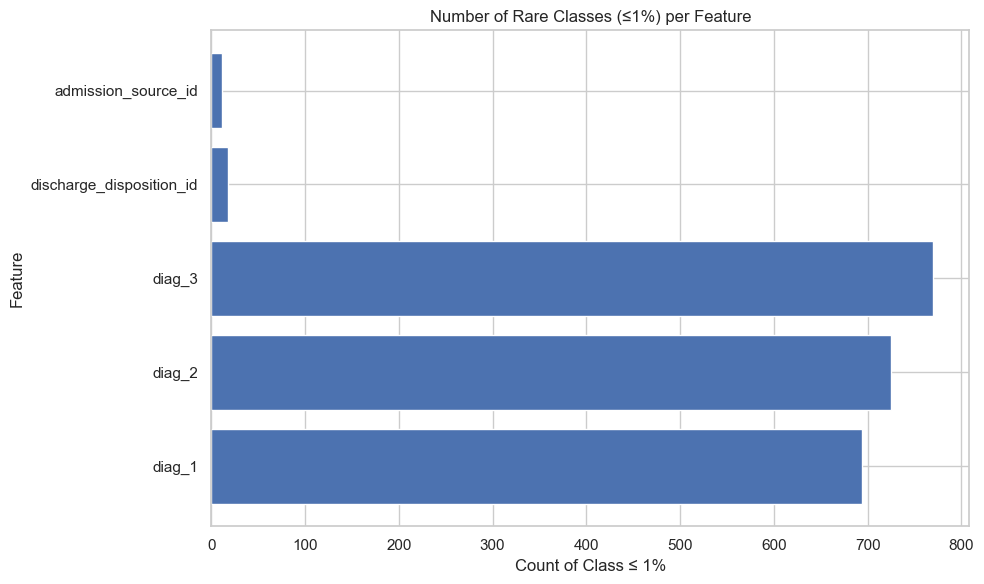

In [37]:
# 1.    Checking the class imbalance of the binary subset
# Creating a copy with purely strings for consistency
df_high_cardinality_clean = df_high_cardinality.astype(str).copy()

# Get normalized value counts for each feature
high_card_dist = df_high_cardinality_clean.apply(lambda x: x.value_counts(normalize=True)).T.fillna(0)

# Plotting (without legend)
plt.figure(figsize=(12, 8))
bottom = None

for class_value in high_card_dist.columns:
    plt.barh(
        high_card_dist.index,
        high_card_dist[class_value],
        left=bottom,
        height=0.5
    )
    if bottom is None:
        bottom = high_card_dist[class_value].copy()
    else:
        bottom += high_card_dist[class_value]

plt.title('Class Distribution Across High-Cardinality Categorical Features (Normalized)')
plt.xlabel('Proportion')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



# 2.    Checking the variance of the high-cardinality subset 
print('Features with a variance greater than 0.90\n', high_card_dist.max(axis=1) > 0.90)

# 3.    Evaluating i) If there exists missing values and ii) the missingnes of the high-cardinality subset 
print("\nNo NaN values found" if df_high_cardinality.isna().sum().sum() == 0 else f"\nNaN values found:\n{df_high_cardinality.isna().sum()}")



# 4.    Checking for Redundancy in Categorical Features
duplicates_lc = df_low_cardinality.T.duplicated(keep=False)
print("\nNo duplicate columns found." if not duplicates_lc.any() else f"\nDuplicate columns found:\n{duplicates_lc[duplicates_lc]}")

# ii) Check features that have high similarity ≥ 95% overlap in values.
print('\nChecking for high overlap between the low-cardinality features (handling NaNs):\n')

high_cols = df_high_cardinality_clean.columns

for i, col1 in enumerate(high_cols):
    for j in range(i + 1, len(high_cols)):
        col2 = high_cols[j]

        # Fill NaNs with a placeholder value before comparison
        s1 = df_high_cardinality_clean[col1].fillna('___missing___')
        s2 = df_high_cardinality_clean[col2].fillna('___missing___')

        overlap = (s1 == s2).mean()

        if overlap >= 0.95:
            print(f"High overlap ({overlap:.2f}) between {col1} and {col2}")


# iii) Check for "outliers" - I.e., classes that are very rare (< 1% of the total count)
rare_classes = []

for col in df_high_cardinality_clean.columns:
    value_ratios = df_high_cardinality_clean[col].value_counts(normalize=True)
    for category, ratio in value_ratios.items():
        if ratio <= 0.01:
            rare_classes.append((category, col))

# Visualizing rare classes found per feature
feature_counts = Counter([col for _, col in rare_classes])
plt.figure(figsize=(10, 6))
plt.barh(list(feature_counts.keys()), list(feature_counts.values()))
plt.title("Number of Rare Classes (≤1%) per Feature")
plt.xlabel("Count of Class ≤ 1%")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Summary

- **Class Distribution:**  
  While most features (like `diag_1`, `diag_2`, and `diag_3`) exhibit a very high number of unique categories, they are somewhat more evenly distributed than expected — though still heavily skewed in parts. In contrast, `admission_source_id` and `discharge_disposition_id` are more imbalanced, with a few categories dominating the majority of the data.

- **Variance and Redundancy:**  
  None of the high-cardinality features were constant or showed extremely low variance. Additionally, no redundant columns or highly overlapping pairs (≥ 95%) were detected, which suggests each feature is capturing distinct information.

- **Missingness:**  
  Missing values are present but relatively limited. Most notably:
  - `diag_3`: 1,423 missing
  - `diag_2`: 358 missing
  - `diag_1`: 21 missing
  Which is manageable and will be taken care of during the data preparation process. 

- **Rare Categories:**  
  A significant number of individual categories within the `diag_*` features appear in fewer than 1% of the observations. These rare categories may contribute noise or sparsity during modeling if not handled properly.

**Conclusion:**  
The high-cardinality subset appears to be of generally good quality — with limited redundancy and manageable missingness. However, special attention should be given to the `diag_*` features due to their high number of rare values. Grouping or simplifying these features during preprocessing may help reduce complexity and improve model performance.


---

#### Chi-Square Test

In [41]:
from scipy.stats import chi2_contingency

# The low-cardinality features that i) do not have high variance ii) not "correlated" and iii) not unbalanced
low_card_cols = [
    'race', 'gender', 'age', 'metformin', 'glipizide',
    'glyburide', 'insulin', 'admission_type_id'
]

# All high-cardinality features 
high_card_cols = [
    'diag_1', 'diag_2', 'diag_3',
    'discharge_disposition_id', 'admission_source_id'
]


# Target must be binary and aligned with the df
target = 'readmitted_binary'  # replace with your binarized target column
df_cat = df_copy[low_card_cols + high_card_cols].copy()
df_cat[target] = df_target  # merge target into same DataFrame

chi_square_results = {}

# Loop through both sets of columns
for col in low_card_cols + high_card_cols:
    try:
        # Drop NaNs just for the test
        contingency_table = pd.crosstab(df_cat[col].dropna(), df_cat[target].loc[df_cat[col].notna()])
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        chi_square_results[col] = {
            'p_value': p,
            'chi2_stat': chi2,
            'dof': dof
        }
    except Exception as e:
        chi_square_results[col] = {'error': str(e)}

# Convert results to DataFrame for readability
chi_square_df = pd.DataFrame(chi_square_results).T.sort_values('p_value')
display(chi_square_df)


,p_value,chi2_stat,dof
discharge_disposition_id,0.000000e+00,1582.583386,25.0
diag_1,6.039414e-92,1777.833107,715.0
diag_3,8.069525e-49,1518.944709,788.0
insulin,3.981889e-41,190.858814,3.0
diag_2,1.845086e-39,1372.226609,747.0
age,6.597923e-21,116.608911,9.0
metformin,1.085303e-12,58.753300,3.0
admission_source_id,8.341155e-06,52.731562,16.0
admission_type_id,3.841108e-04,26.657064,7.0
glipizide,9.272622e-03,11.508184,3.0


#### Summary of Chi-Square Tests
The Chi-Square test was performed to evaluate the **statistical association** between each categorical feature and the binary target variable (`readmitted_binary`, indicating whether a patient was readmitted within 30 days).

Below is a summary of key observations based on the test statistics:

- **Strong Association**:  
  Features such as `discharge_disposition_id`, `diag_1`, `diag_2`, `diag_3`, and `insulin` showed **very strong statistical associations** with the target variable (p-value ≪ 0.05). These features are likely to be **important for prediction**.

- **Moderate Association**:  
  `age`, `metformin`, `admission_source_id`, `admission_type_id`, and `glipizide` also show **statistically significant associations** (p < 0.05), though with lower chi-squared values.

- **No Significant Association**:  
  `race`, `glyburide`, and `gender` had **p-values > 0.05**, indicating **no statistically significant dependence** on the readmission outcome in this dataset.

Note: Statistical significance **does not imply causation**, and features with weak associations may still hold predictive power when combined with others in a model.


#### Target-Rate by Category 

In [47]:
# Define your target variable if not already done
df_copy['readmitted_binary'] = df_copy['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Define your column groups (update these if you already defined them somewhere else)
low_card_cols = [
    'race', 'gender', 'age', 'metformin', 'glipizide', 'glyburide', 'insulin', 
    'admission_type_id'
]

high_card_cols = [
    'admission_source_id', 'discharge_disposition_id', 
    'diag_1', 'diag_2', 'diag_3'
]

# Store results
top_target_rate_rows = []

# Loop through features
for col in low_card_cols + high_card_cols:
    try:
        group = df_copy.groupby(col)['readmitted_binary'].agg(['mean', 'count']).reset_index()
        group = group.rename(columns={
            col: 'Category',
            'mean': 'Readmission Rate',
            'count': 'Sample Count'
        })
        group['Feature'] = col
        
        # Filter: only include categories with >= 50 samples
        group = group[group['Sample Count'] >= 50]
        
        # Sort and get top 3
        top_3 = group.sort_values(by='Readmission Rate', ascending=False).head(3)
        top_target_rate_rows.append(top_3)

    except Exception as e:
        print(f"Error in column {col}: {e}")

# Combine all into a single DataFrame
target_rate_summary_df = pd.concat(top_target_rate_rows, ignore_index=True)

# Reorder columns for display
target_rate_summary_df = target_rate_summary_df[['Feature', 'Category', 'Readmission Rate', 'Sample Count']]

# Display
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: sort for better readability
target_rate_summary_df_sorted = target_rate_summary_df.sort_values(by='Readmission Rate', ascending=False)

# Show as table (Jupyter)
display(target_rate_summary_df_sorted)

,Feature,Category,Readmission Rate,Sample Count
26,discharge_disposition_id,15,0.444444,63
29,diag_1,V58,0.416667,228
27,discharge_disposition_id,28,0.366906,139
35,diag_3,581,0.309278,97
28,discharge_disposition_id,22,0.276969,1993
32,diag_2,205,0.275862,58
30,diag_1,250.41,0.263736,91
33,diag_2,250.41,0.250000,228
36,diag_3,536,0.247191,267
31,diag_1,567,0.245614,57


#### Summary of Target-Rate by Cateogy
Highest Readmission Rates by Category:
- `discharge_disposition_id = 15` → **44.4%** (n = 63)
- `diag_1 = V58` → **41.7%** (n = 228)
- `discharge_disposition_id = 28` → **36.7%** (n = 139)
- Other notable high-risk categories appear across diagnostic codes (`diag_1`, `diag_2`, `diag_3`) and `admission_source_id`.

#### 🧠 Key Observations:
- Diagnostic and discharge-related features contain **categories with exceptionally high readmission rates**, suggesting strong clinical relevance.
- Several medication-related and demographic features (`glipizide`, `insulin`, `age`, `race`) show **relatively moderate target rates**, generally under 15%.
- Features like `gender`, `glyburide`, and `admission_type_id` have **minimal variation** in readmission rates across categories, potentially offering less discriminatory power alone.

> As with all univariate summaries, **target rates should be interpreted with caution** — especially for categories with **low sample sizes**. Multivariate modeling will better capture combined effects.


### Numerical Data

The goal of this section is to explore the numerical features in a way that reveals their distributions, variability, and relationships. This will help in detecting problematic data, decide if we need to perform trnsformations and identify featrues that are potentially informative, redundant, or noisy. 


#### Displaying The Numerical Data

In [27]:
df_numerical.head(10)

,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
0,2278392,8222157,1,41,0,1,0,0,0,1
1,149190,55629189,3,59,0,18,0,0,0,9
2,64410,86047875,2,11,5,13,2,0,1,6
3,500364,82442376,2,44,1,16,0,0,0,7
4,16680,42519267,1,51,0,8,0,0,0,5
5,35754,82637451,3,31,6,16,0,0,0,9
6,55842,84259809,4,70,1,21,0,0,0,7
7,63768,114882984,5,73,0,12,0,0,0,8
8,12522,48330783,13,68,2,28,0,0,0,8
9,15738,63555939,12,33,3,18,0,0,0,8


In [28]:
df_numerical.describe()

,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


#### Observations of the Numerical Data
The numerical dataset contains 10 features. A quick inspection reveals that two of them — `encounter_id` and `patient_nbr` — are identifier columns. While they do not carry predictive numerical value, they might still be useful for grouping purposes (e.g., analyzing repeat admissions per patient) later.

No clear signs of missing or erroneous values are visible at this stage, and most features appear to contain valid numerical values. However, further checks are required to confirm this and to detect any outliers, impossible values, or data quality issues. Overall, the numerical data looks relatively clean and potentially informative.
 

#### Inspecting the Numerical Data for Missing Values, Wierd Values, Impossible Values and Outliers

No string values found in the numerical DataFrame
No negative values found in the numerical DataFrame
No NaN values found in the numerical DataFrame


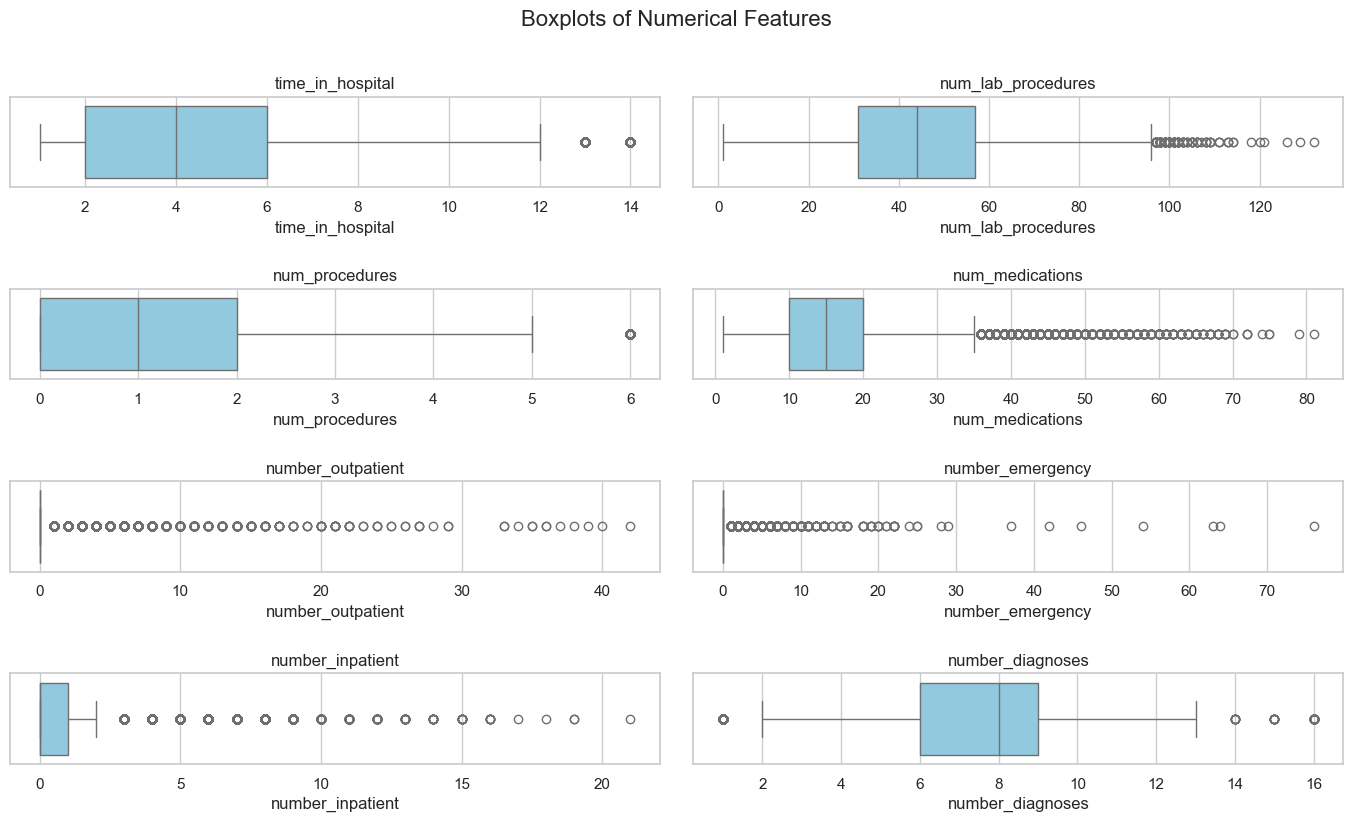

In [29]:
# Firstly checking for string values in the numerical DataFrame
if len(df_numerical[df_numerical.select_dtypes(include=['object']).columns].isnull().sum()) < 1:
    print('No string values found in the numerical DataFrame')
else:
    print('String values found in the numerical DataFrame')
    display(df_numerical[df_numerical.select_dtypes(include=['object']).columns].isnull().sum())

# Checking for negative values
if df_numerical[df_numerical < 0].count().sum() == 0:
    print('No negative values found in the numerical DataFrame')
else:
    print('Negative values found in the numerical DataFrame')
    display(df_numerical[df_numerical < 0].count().sum())

# Checking for NaN values
if df_numerical.isna().sum().sum() == 0:
    print('No NaN values found in the numerical DataFrame')
else:
    print('NaN values found in the numerical DataFrame')
    display(df_numerical.isna().sum())

# Removing false features from the DataFrame - Has been checked and can be used later if one wants. For now, unneccasary
# to keep these in the DataFrame. 
df_numerical_dropped = df_numerical.drop(columns=['encounter_id', 'patient_nbr'], axis=1).copy()

# Checking for Outliers, wierd values and imposible values - using a Boxplots
plt.figure(figsize=(14, 10))
plt.suptitle("Boxplots of Numerical Features", fontsize=16)

# Loop through numerical columns and plot each as a subplot
for i, col in enumerate(df_numerical_dropped.columns, 1):
    
    plt.subplot(5, 2, i) 
    sns.boxplot(x=df_numerical[col], color='skyblue')
    plt.title(col)
    plt.tight_layout(pad=2.0)

plt.show()

#### Summary of findings From The inspections Of The Numerical Data
The numerical data appears to be in significantly better condition than the categorical data. No missing values (`NaN`), string-based placeholders, or negative values were found. Most features fall within expected ranges, and the distribution of values looks reasonable overall.

However, the following observations are worth noting:

- **`number_outpatient`**, **`number_emergency`**, and **`number_inpatient`** display extreme right-skew, with maximum values reaching up to 76 despite mean values close to 0. These are likely rare events but may warrant validation through domain expertise.
  
- **Outliers** are visible across many features:
  - `num_medications`: Several values exceed 60.
  - `num_lab_procedures`: Some cases report over 100 lab procedures.
  - `number_diagnoses`: Has a max of 16, which may exceed common diagnostic recording limits.

These outliers are not necessarily errors but should be kept in mind during modeling. Transformation or robust modeling techniques might be appropriate, depending on the use case. In conclusion, no duplicate features, constant columns, or structurally broken attributes were found. The dataset seems well-formed and informative, with a few edge cases flagged for further consideration.

---

### Exploring Correlations of the Numerical Data
In this section, we'll explore different types of correlations within the numerical dataset. This includes:

- Relationships between numerical features
- Correlations with the target variable
- Pairwise visualizations of selected attributes
- A brief multicollinearity check

#### Correlation between numerical features

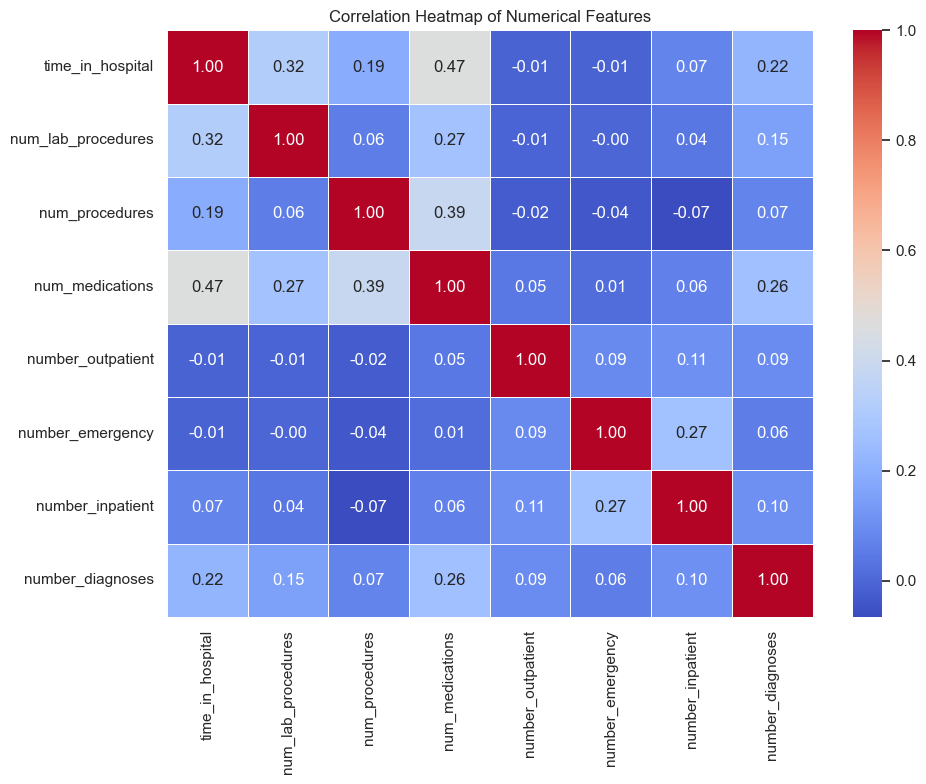

In [30]:
# Calculate correlation matrix
corr_matrix = df_numerical_dropped.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


#### Summary: Correlation Between Numerical Features

To assess how the numerical features relate to one another, we compute and visualize a **Pearson correlation heatmap**. This helps identify potential **redundancies** or **multicollinearity** among the features, as well as showing dependencies. 

**Key Observations:**
- Most feature pairs exhibit **low correlation**, suggesting they carry **independent information**.
- The strongest observed correlation is between `time_in_hospital` and `num_medications` at **0.47**, which is still not high enough to warrant concern.
- No features show correlation high enough (≥0.8) to require removal or consolidation.

Conclusion: **All features will be retained**, as they may contribute uniquely to the predictive model.


#### Correlation with the target variable

The Target variable has been successfully binarized and is of type: int64


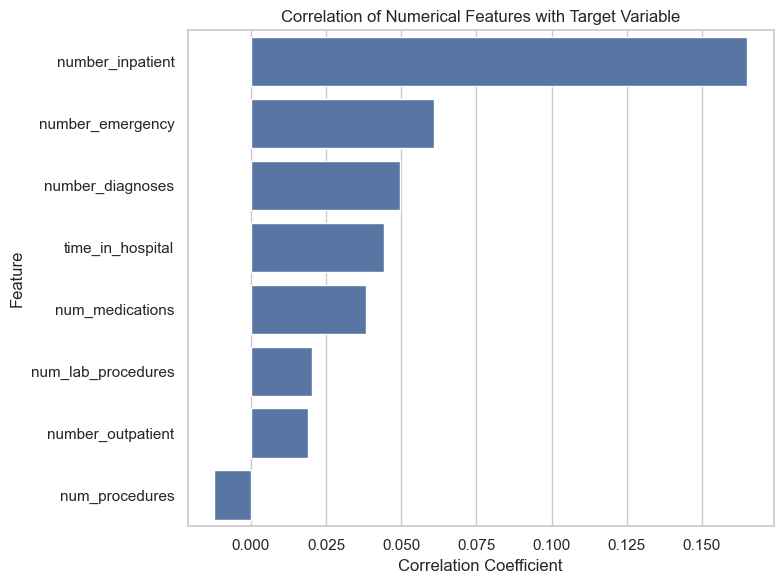

In [31]:
# Establishing the target variable 
df_target = df_copy[target].copy()

# Binirizing the target variable
df_target = df_target.apply(lambda x: 1 if x == '<30' else 0) # Remember - target variable is string 

# Converting DataFrame to type int 
df_target = df_target.astype(int)

# Quick check to see if the target variable has been binarized correctly
if len(df_target) != len(df_numerical_dropped) or df_target.nunique() != 2:
    print('There is a problem with the target variable. Please check the data and code')
else:
    print('The Target variable has been successfully binarized and is of type:', df_target.dtype)

# Showing the correlation between the target variable and the numerical features
correlations = df_numerical_dropped.corrwith(df_target)
correlations = correlations.sort_values(key=abs, ascending=False)

# Plot it
plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.values, y=correlations.index)
plt.title("Correlation of Numerical Features with Target Variable")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


#### Summary: Correlation with the target variable
To assess which numerical features may contain signal for predicting hospital readmission, we computed the Pearson correlation coefficient between each feature and the binary target variable (`readmitted`).

- The most positively correlated features were:
  - `number_inpatient` (~0.16)
  - `number_emergency` (~0.06)
  - `number_diagnoses` (~0.05)

No feature showed strong linear correlation with the target, which is expected in real-world clinical data These results suggests that:
  - No individual feature dominates prediction, meaning the model must learn from combinations of features.
  - The target variable is not trivially explained by any one attribute, helping reduce overfitting risk.
  - Features like `number_inpatient` could still be informative and worth emphasizing during feature engineering.

Overall, the analysis highlights features that may contribute some predictive value — even if only weakly on their own. In this case, it appears that all numerical features carry at least a small amount of signal. While no single feature strongly correlates with the target, this is typical in clinical datasets, where multiple weak signals are often combined to make meaningful predictions. This sets the stage for models that can pick up on subtle patterns across features, rather than relying on any one attribute alone.



#### Pairwise Comparisons Of The Attributes 

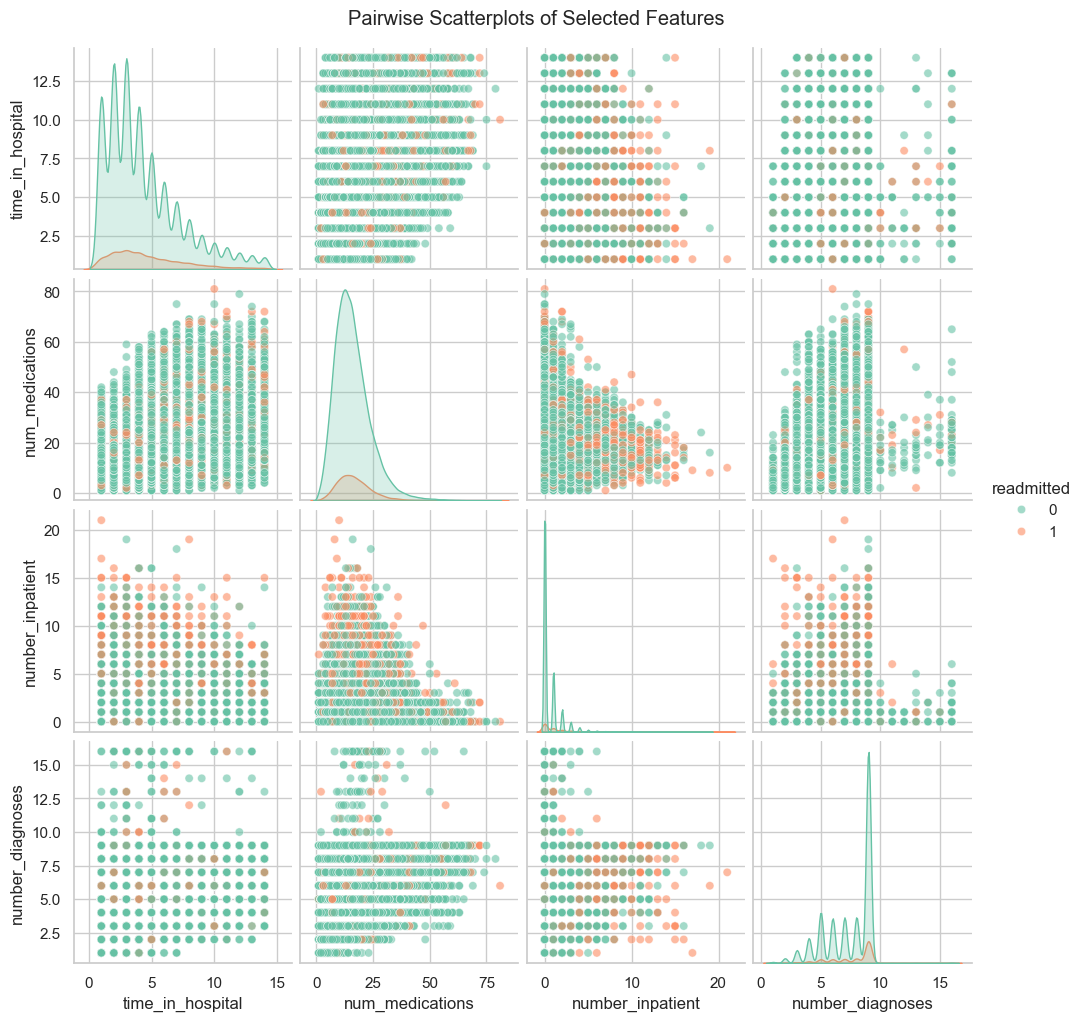

In [32]:
# Selecting the relevant numerical features
selected_features = [
    'time_in_hospital',
    'num_medications',
    'number_inpatient',
    'number_diagnoses'
]

# Combine selected features with the target
df_pairwise = df_numerical_dropped[selected_features].copy()
df_pairwise['readmitted'] = df_target

# Plotting pairplot colored by target
sns.pairplot(df_pairwise, hue='readmitted', palette='Set2', plot_kws={'alpha': 0.6})
plt.suptitle("Pairwise Scatterplots of Selected Features", y=1.02)
plt.show()

#### Summary: Pairwise Comparisons Of The Attributes 
The pairwise scatterplots give a more visual insight into how selected numerical features interact, both with each other and with the target variable (`readmitted`). While a few trends are visible — such as mild associations between length of hospital stay and medications, or frequent inpatient visits correlating with higher readmission — there is significant overlap between the classes.

This reinforces that **no single feature is clearly separable**, and the predictive signal will likely emerge from **interactions across multiple variables**. These visual checks help confirm that we are not missing any glaring data issues or strong linear patterns, and that the dataset will benefit from a multivariate modeling approach.


#### Multicollinearity Check
Multicollinearity refers to the situation where two or more features are highly correlated with each other. While not always a problem, it can complicate interpretation and affect the stability of certain models — particularly linear models. In this step, we assess multicollinearity using the Variance Inflation Factor (VIF), which quantifies how much the variance of a feature is inflated due to its correlation with other features. Features with high VIF values may be redundant and considered for removal or dimensionality reduction.


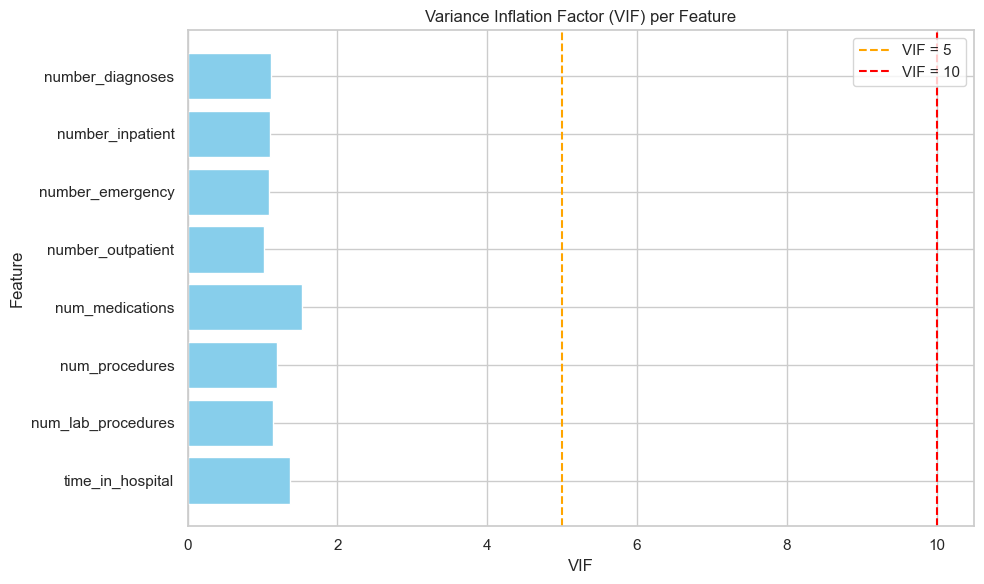

In [34]:
# Add constant for intercept in VIF calculation
X = add_constant(df_numerical_dropped)

# Create a DataFrame of VIF values
vif_df = pd.DataFrame()
vif_df['Feature'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Drop the constant row (not needed in plot)
vif_df = vif_df[vif_df['Feature'] != 'const']

# Plotting the resulting VIF values 
plt.figure(figsize=(10, 6))
plt.barh(vif_df['Feature'], vif_df['VIF'], color='skyblue')
plt.title('Variance Inflation Factor (VIF) per Feature')
plt.xlabel('VIF')
plt.ylabel('Feature')
plt.axvline(x=5, color='orange', linestyle='--', label='VIF = 5')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10')
plt.legend()
plt.tight_layout()
plt.show()



#### Summary: Multicollinearity Check
To ensure that our numerical features are not strongly linearly correlated with each other, we calculate the **Variance Inflation Factor (VIF)** for each feature.

Multicollinearity can introduce instability in linear models and distort feature importance. A VIF value of:

- **Above 10** is generally considered problematic
- **Between 5–10** suggests moderate correlation
- **Below 5** indicates no concerning multicollinearity

In our analysis, all numerical features showed VIF scores well below 5, with the majority around 1–2. This suggests:

- No features are redundant due to linear dependence
- All numerical variables can be safely retained for modeling
- No action is needed at this stage for multicollinearity

This step confirms that our dataset is well-conditioned for downstream modeling, particularly for interpretable models or those sensitive to feature collinearity.


## ✅ Conclusion

This notebook performed a comprehensive exploration of the dataset, focusing on **categorical and numerical features** in preparation for downstream machine learning tasks. Key findings include:

### 📌 Categorical Features
- **Low-cardinality features** revealed several redundant variables with high overlap, many near-constant, and some with missing values (`race`).
- **High-cardinality features** were more informative, especially `diag_1`, `diag_2`, and `diag_3`, though they include many rare categories.
- **Chi-square tests** revealed strong associations between categorical features like `discharge_disposition_id`, `diag_1`, `age`, and the target variable.
- **Target rate analysis** identified diagnostic and discharge categories with significantly higher readmission rates.

### 📌 Numerical Features
- No missing, string, or negative values were found. Features like `encounter_id` and `patient_nbr` were correctly excluded as identifiers.
- Several features (e.g., `number_outpatient`, `number_emergency`) showed extreme outliers but were not clearly erroneous.
- **Correlation analysis** found low overall multicollinearity and modest correlations with the target — `number_inpatient` was the strongest.
- **Pairwise plots** revealed subtle patterns between key numerical attributes and readmission.
- **VIF analysis** confirmed no critical multicollinearity, supporting inclusion of all numerical variables for modeling.

> Overall, the dataset appears clean and well-suited for modeling, even though less true for the categorical data. While no single feature dominates predictiveness, the combination of features — especially diagnostic, discharge, and hospitalization history — are likely to contribute meaningful signal to a robust machine learning pipeline.

Next we will handle the pre-processing of the data.
